## Titanic Survival Prediction

Start by importing the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


Let's start by fetching the data from train.csv. The specific method is pd.read_csv(). We can also use the df.head(N) method to display the first N rows. Lastly, use the df.shape property to see the dimensions of the data frame.

In [2]:
df = pd.read_csv('train.csv')
print("Dataset shape:",df.shape)
df.head(10)

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


The column descriptions are the following.

| Column | Description |
| :--- | :--- |
| **PassengerId** | Unique ID for each passenger |
| **Survived** | 0 = Did not survive, 1 = Survived |
| **Pclass** | Ticket class: 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Name** | Passenger name |
| **Sex** | Gender |
| **Age** | Age in years |
| **SibSp** | Number of siblings/spouses aboard |
| **Parch** | Number of parents/children aboard |
| **Ticket** | Ticket number |
| **Fare** | Passenger fare |
| **Cabin** | Cabin number |
| **Embarked** | Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton |

## Dataset Overview Analysis

There are a number of methods we can use to get a sense of the overall dataset.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
df.describe() # Display summary statistics for numerical columns

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
#include specifies the type of column, and doing "string" or "object" will handle the string or object columns respectively
df.describe(include="string")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## Missing Value Analysis


The isna() method checks if an element is missing/NA  (NA means not available) for every element in the dataframe (returning a boolean). Then, we can use the sum() method to collapse along each column. The end result is a series with an ID for column titles and a value of the number of NA values in that column.

In [6]:
print(df.isna().head(4))
df.isna().sum() # Count of missing values in each column

   PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0        False     False   False  False  False  False  False  False   False   
1        False     False   False  False  False  False  False  False   False   
2        False     False   False  False  False  False  False  False   False   
3        False     False   False  False  False  False  False  False   False   

    Fare  Cabin  Embarked  
0  False   True     False  
1  False  False     False  
2  False   True     False  
3  False  False     False  


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Let's create a dataframe with rows being the columns and the two columns being missing count and missing percentage. It's important to note that the IDs from the series are being aligned to create the rows. Within this dataframe, let's also delete the rows (columns from the original dataframe) where there are no missing elements.

In [7]:
missingdf =pd.DataFrame({
    "Missing Cnt": df.isna().sum(),
    "Missing %": ((df.isna().sum() / df.shape[0]) * 100).round(2)
})

missingdf = missingdf[missingdf["Missing Cnt"] > 0].sort_values("Missing %", ascending=False)
missingdf

,Missing Cnt,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


Now, let's use matplotlib to create graphs for this data. Some methods and properties referenced:
- *plt.subplots* creates a figure environment where multiple graphs can be placed in one figure. By default it is 1, 1 (so only one graph contained), but you can set it to (rows, columns).
- *fig* is the entire image/canvas (the stage that the graphs go on)
- *ax* is the actual plotting area where the chart goes
- *figsize* defines the size of the canvas (how large you want the image to be in the Notebook)

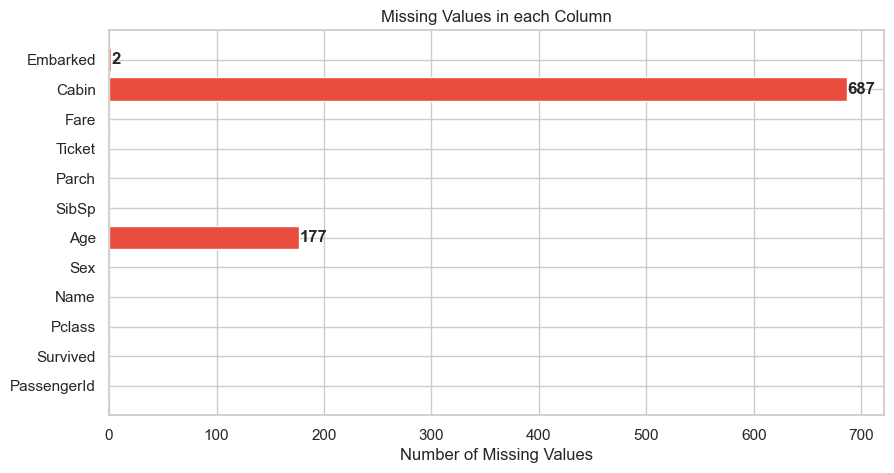

In [8]:
fig ,ax = plt.subplots(figsize=(10,5)) # ax only if there is one chart
colors =["#e74c3c" if df[col].isna().any() > 0 else "#2ecc71" for col in df.columns]
ax.barh(df.columns, df.isna().sum(), color=colors)
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values in each Column")

for i ,v in enumerate(df.isna().sum()):
    if(v>0):
       ax.text(v + 0.5, i ,v , va='center', fontweight="bold") # va centers vertically on the column

## Target Value Analysis


Let's read the details about the target variable, which is "Survived". value_counts() creates a new series that records the number of times each unique value appears in a column (ID is el value, value is count).

In [9]:
survived=df['Survived'].value_counts()
survived

Survived
0    549
1    342
Name: count, dtype: int64

Let's create two side-by-side graphs to show the results.

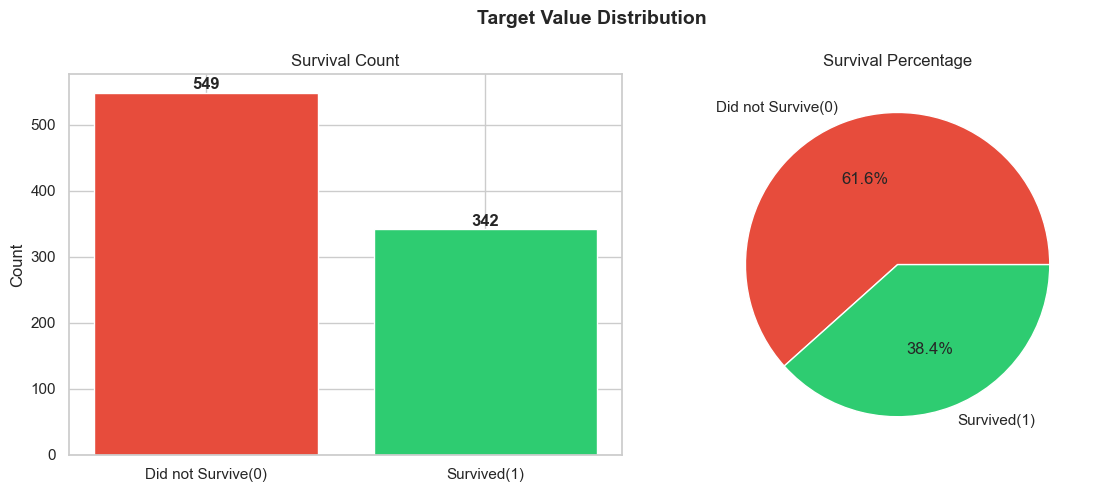

In [10]:
fig , axes = plt.subplots(1,2,figsize=(12,5))
axes[0].bar(["Did not Survive(0)" , "Survived(1)"], survived.values, color=["#e74c3c","#2ecc71"])
axes[0].set_title("Survival Count")
axes[0].set_ylabel("Count")

for i ,v in enumerate(survived.values):
    axes[0].text(i , v + 5 ,v , ha='center', fontweight="bold") # ha centers horizontally on the column

axes[1].pie(survived.values, labels=["Did not Survive(0)" , "Survived(1)"], autopct='%1.1f%%', colors=["#e74c3c","#2ecc71"])
axes[1].set_title("Survival Percentage")

plt.suptitle("Target Value Distribution",fontsize =14 , fontweight="bold")
plt.tight_layout()

## Univariate Analysis
### Numerical Features

Let's use matplotlib to get a sense of each of our variables independently first. One useful note is that if we have a subplot grid, we typically need to call *axes[r, c]* to process the graph at row r and column c. However, by taking *axes.flatten()*, we can turn the 2d array into a 1d array where the index of the graph is its position if you were reading from the start ($index = r \cdot width + c$). Other methods/properties referenced:
- *.dropna()* drops all NA values in a Series and all rows with at least one NA in a dataframe
- *ax.hist()* creates histograms/frequency distributions
- *bins* defines the number of separated columns the continuous data is separated into
- *axvline* creates an infinite vertical line spanning across an Axes plot

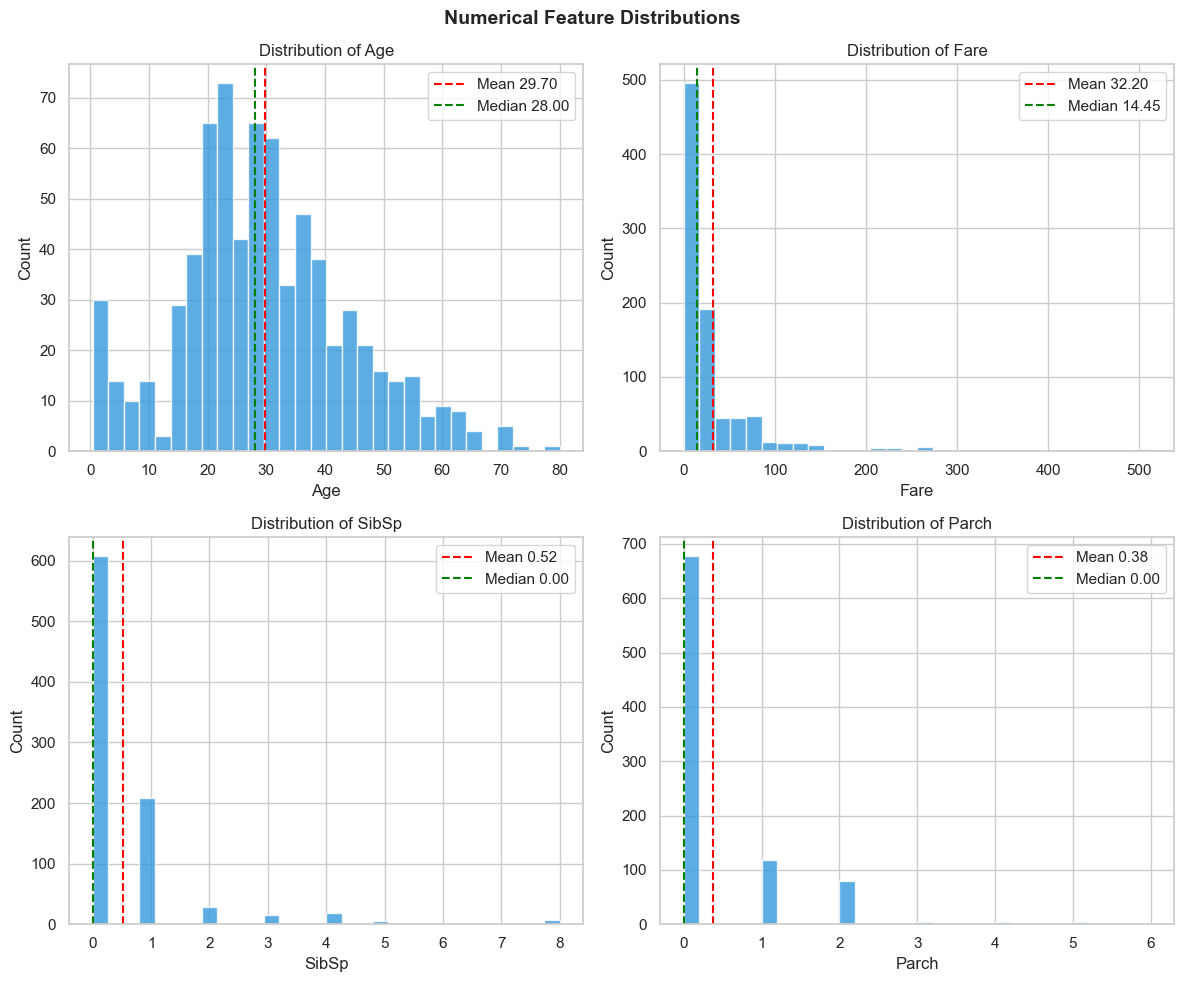

In [11]:
numerical_cols = ["Age", "Fare", "SibSp", "Parch"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten() # flatten so you can call by the Nth like you're reading

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="#3498db", edgecolor="white", alpha=0.8) 
    axes[i].set_title("Distribution of " + col)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean {df[col].mean():.2f}") #draw mean line
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label=f"Median {df[col].median():.2f}") #draw median line
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Beyond using a histogram for feature distribution, we can also use a boxplot and search for outliers. *boxplot()* draws a boxplot with the box being from Q1 to Q3 and whiskers going out an additional $\pm 1.5 \text{ IQR}$ ($\text{IQR} = Q3 - Q1$)

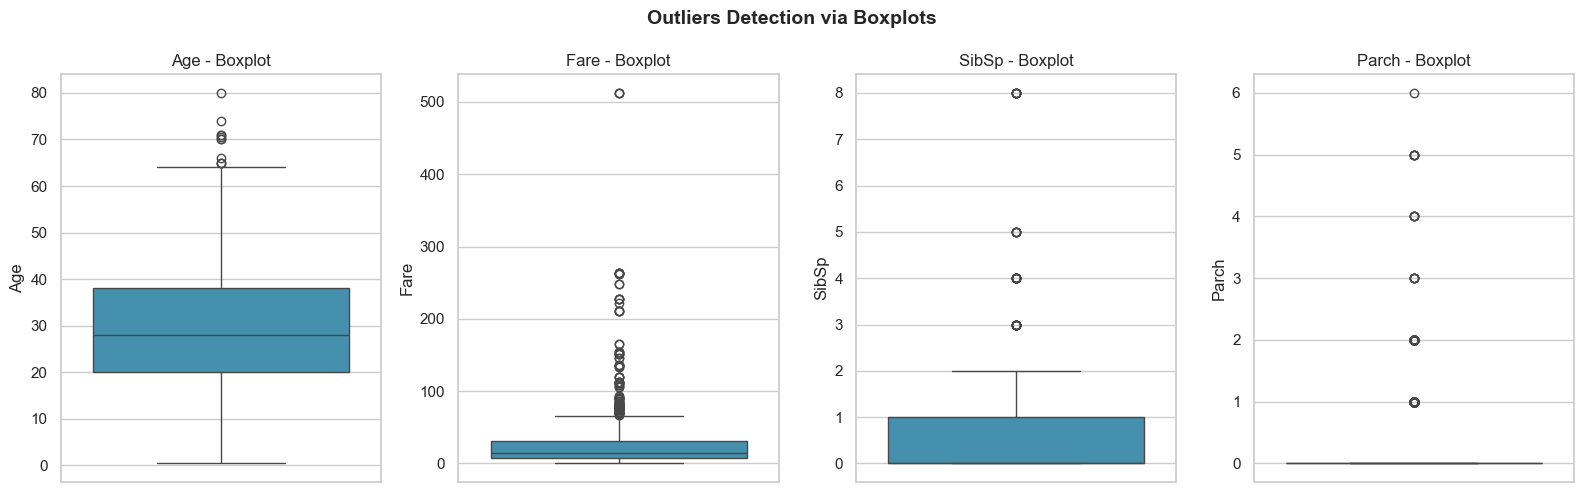

In [12]:
fig , axes =plt.subplots(1 , 4, figsize=(16 , 5))

for i ,col in enumerate(numerical_cols):
    sns.boxplot(data=df[col], ax=axes[i], color="#3498bd")
    axes[i].set_title(f"{col} - Boxplot")
   
plt.suptitle("Outliers Detection via Boxplots", fontsize=14, fontweight="bold")  
plt.tight_layout()
plt.show()


## Categorical Features

We can also study the distribution of categorical features (String or objects). It's useful to note that *value_counts()* sorts by descending frequency by default. You can prevent sorting by passing in *value_counts(sort=False)* or sorting by index with *.sort_index()* after value_counts.

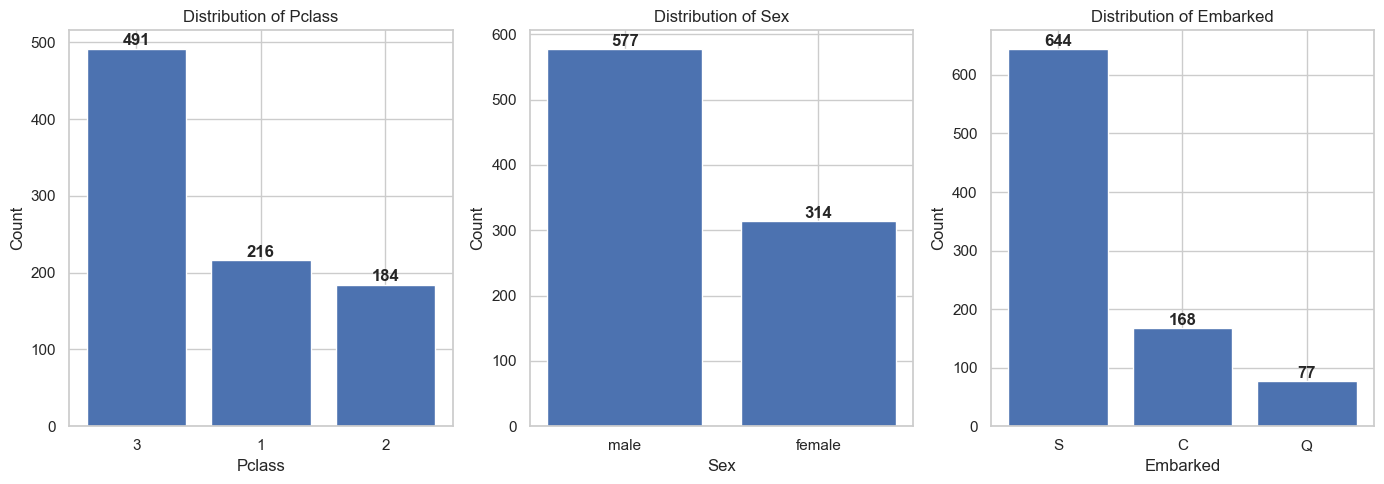

In [13]:
# Distribution of Categorical Features
categorical_cols = ["Pclass", "Sex", "Embarked"]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts() # sorts by descending order by default
    axes[i].set_title(f"Distribution of {col}")
    axes[i].bar(counts.index.astype(str), counts.values, edgecolor="white")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

    for j , v in enumerate(counts):
        axes[i].text(j , v + 5 ,str(v) , ha='center', fontweight="bold") # ha centers horizontally on the column    

plt.tight_layout()
plt.show()

## Bivariate Analysis - Survival vs Features

Now that we have done univariate analysis, observing properties of each variable independently, we can move on to bivariate analysis. Specifically, comparing how each factor relates to the target variable (Survived). First, we can see how the categorical feature values related to survival rate. We include *astype(str)* to prevent the x values from filling in any continious values if the labels are numeric.

You can use the df.groupby() method. This groups all the different values from different properties. The end result is a series with ID of the property values and some final result based on what method you call onto the groupby.

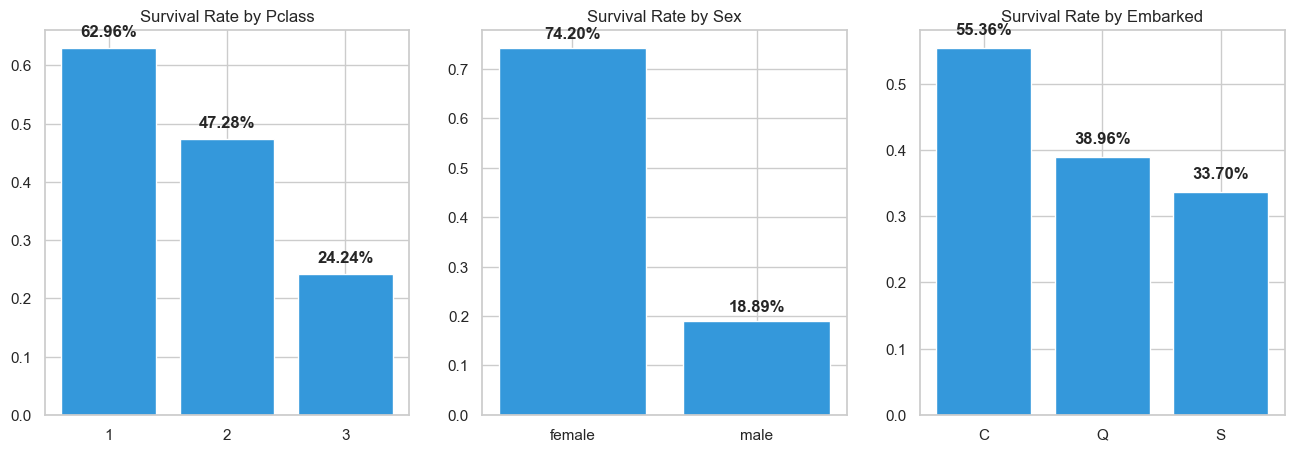

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(categorical_cols):
    axes[i].set_title(f"Survival Rate by {col}")
    percents = df.groupby(col)["Survived"].mean()
    
    axes[i].bar(percents.index.astype(str), percents.values, color="#3498db")
    
    # Add percentage text on top of the bars
    for j, v in enumerate(percents):
        axes[i].text(j, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")

We can also consider survival based on the combination of sex and class.

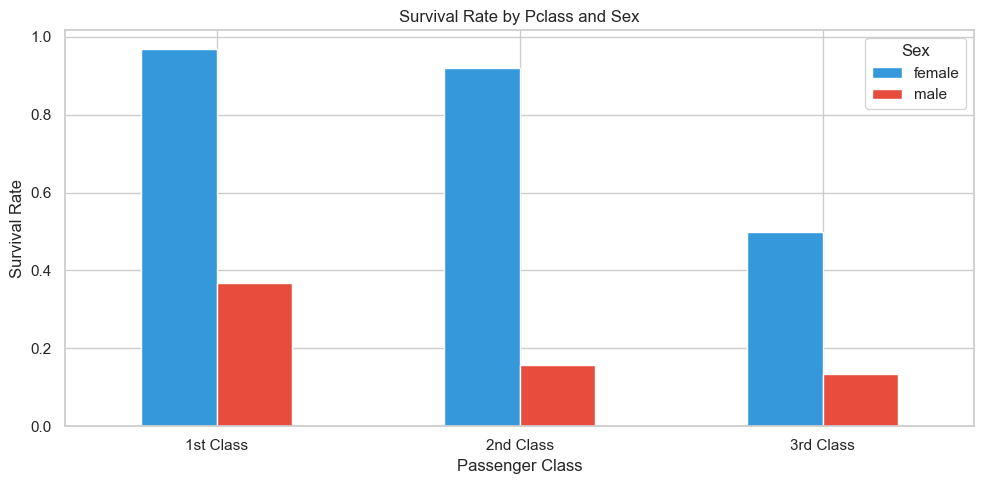

In [15]:
fig ,ax = plt.subplots(figsize=(10,5))
survival_grouped = df.groupby(["Pclass","Sex"])["Survived"].mean().unstack()
survival_grouped.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"])
ax.set_title("Survival Rate by Pclass and Sex")
ax.set_ylabel("Survival Rate")
ax.set_xlabel("Passenger Class")
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"], rotation=0)
ax.legend(title="Sex")
plt.tight_layout()
plt.show()

We can also study the age distribution by survival.

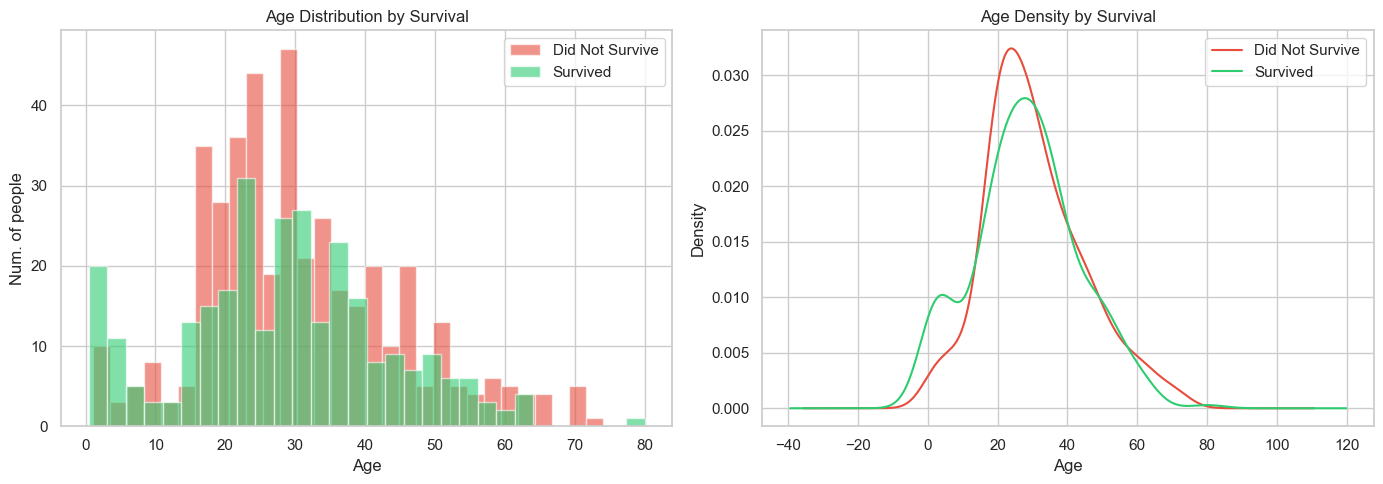

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

survived_ages = df[df["Survived"] == 1]["Age"].dropna()
died_ages = df[df["Survived"] == 0]["Age"].dropna()
axes[0].hist(died_ages, bins=30, alpha=0.6, color="#e74c3c", label="Did Not Survive")
axes[0].hist(survived_ages, bins=30, alpha=0.6, color="#2ecc71", label="Survived")

axes[0].legend()
axes[0].set_ylabel("Num. of people")
axes[0].set_xlabel("Age")
axes[0].set_title("Age Distribution by Survival")

died_ages.plot.kde(ax=axes[1], color="#e74c3c", label="Did Not Survive")
survived_ages.plot.kde(ax=axes[1], color="#2ecc71", label="Survived")

axes[1].set_title("Age Density by Survival")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
plt.show()


Now, let's study the average fare for those that survived and those that didn't.

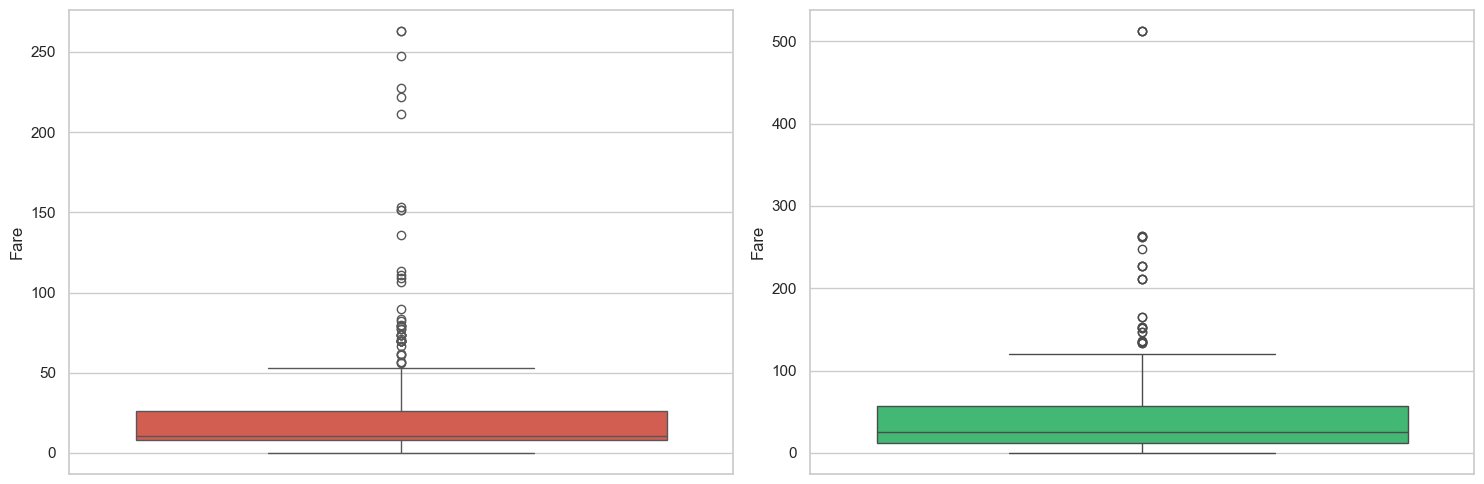

Average fare - Survived: $48.40
Average fare - Did Not Survive: $22.12


In [17]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

died_fares = df[df["Survived"] == 0]["Fare"]
survived_fares = df[df["Survived"] == 1]["Fare"]

sns.boxplot(y=died_fares, ax=axes[0], color="#e74c3c")
sns.boxplot(y=survived_fares, ax=axes[1], color="#2ecc71")

plt.tight_layout()
plt.show()

print(f"Average fare - Survived: ${survived_fares.mean():.2f}")
print(f"Average fare - Did Not Survive: ${died_fares.mean():.2f}")


Analyzing family sizes and survival by family size.

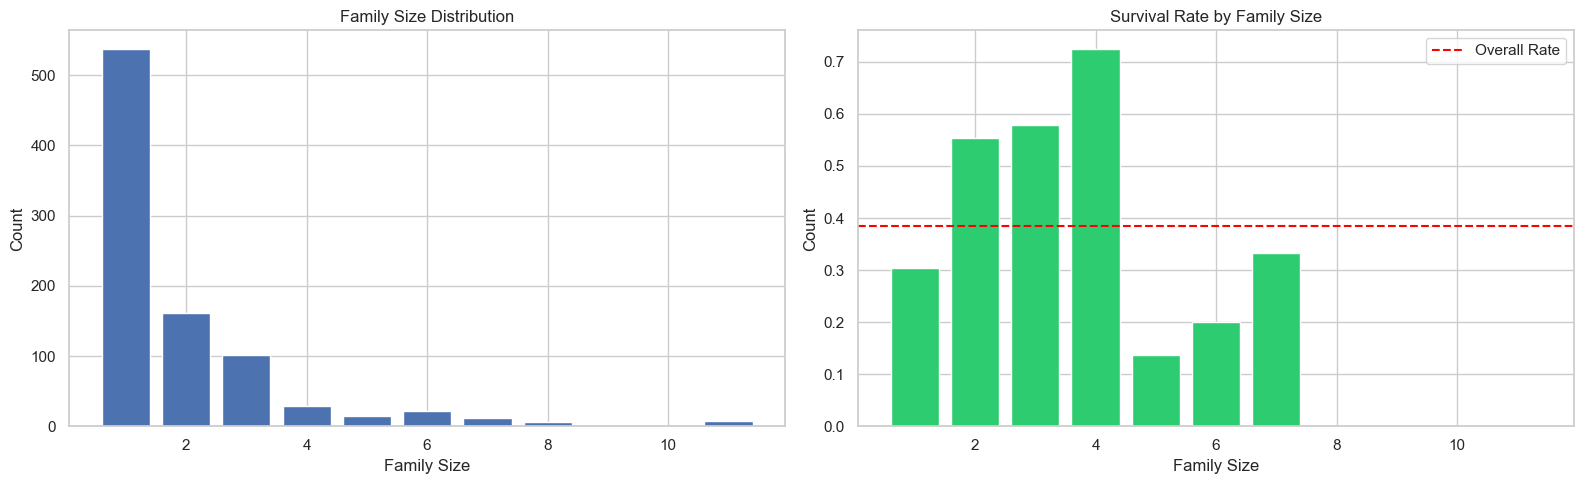

In [18]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
family_counts = df["FamilySize"].value_counts()

# Family size distribution

axes[0].bar(family_counts.index, family_counts.values)
axes[0].set_title("Family Size Distribution")
axes[0].set_xlabel("Family Size")
axes[0].set_ylabel("Count")

# Survival rate by family size

family_survive_rates = df.groupby("FamilySize")["Survived"].mean()
axes[1].bar(family_counts.index, family_survive_rates.values, color="#2ecc71")
axes[1].set_title("Survival Rate by Family Size")
axes[1].set_xlabel("Family Size")
axes[1].set_ylabel("Count")
axes[1].axhline(y=df["Survived"].mean(), color="red", linestyle="--", label="Overall Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

## Correlation Analysis

Now, we can study how all the variables interact with each other.

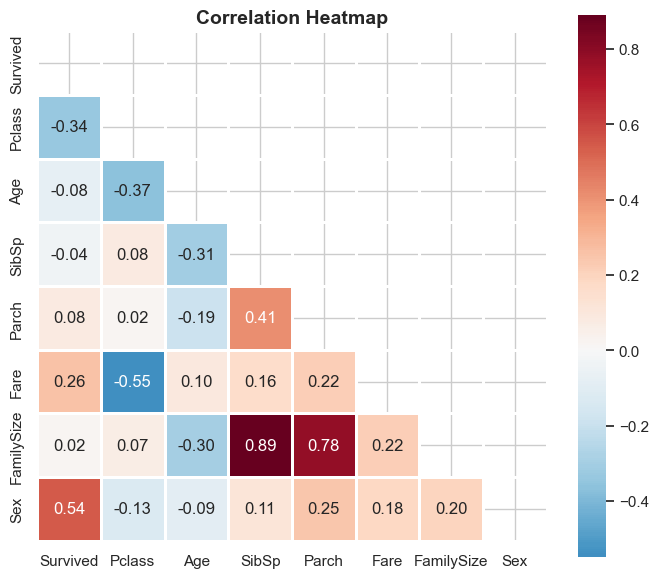

In [19]:
numeric_df =df[["Survived","Pclass","Age","SibSp","Parch","Fare","FamilySize"]].copy()
numeric_df["Sex"] =df["Sex"].map({"male" : 0, "female" : 1}) # Convert categorical variable "

fig ,ax = plt.subplots(figsize=(7,6))
corr = numeric_df.corr() # Calculate the correlation matrix
mask = np.triu(np.ones_like(corr, dtype=bool)) # Create a mask for the upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",center=0, square=True, linewidths=1, ax=ax)

ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

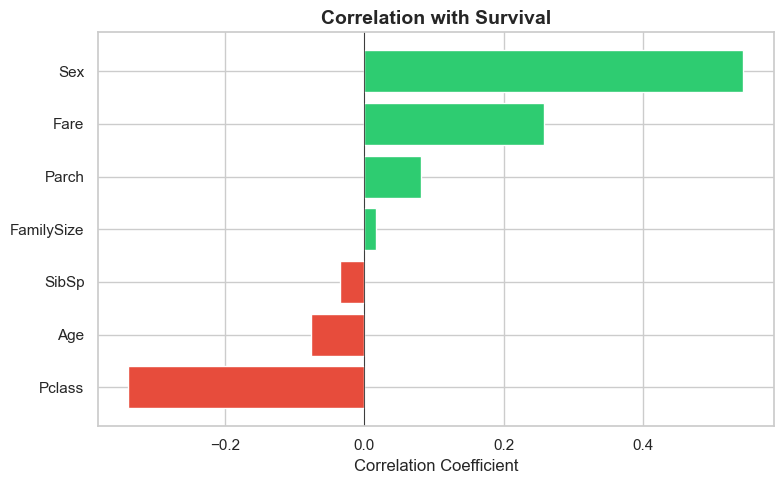

In [20]:
# Correlation with target Survived
# 1. Isolate the "Survived" column from our correlation matrix
target_corr = corr["Survived"].drop("Survived").sort_values(ascending=True)

# 2. Assign red for negative correlations and green for positive correlations
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]

fig, ax = plt.subplots(figsize=(8, 5))

# 3. Plot a horizontal bar chart
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_title("Correlation with Survival", fontsize=14, fontweight="bold")
ax.set_xlabel("Correlation Coefficient")

# 4. Add a vertical line at 0.0 to clearly separate positive and negative
ax.axvline(x=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

Lastly, we can analyze based on the person's title (included in Name)

Text(0.5, 1.0, 'Survival Rate by Title')

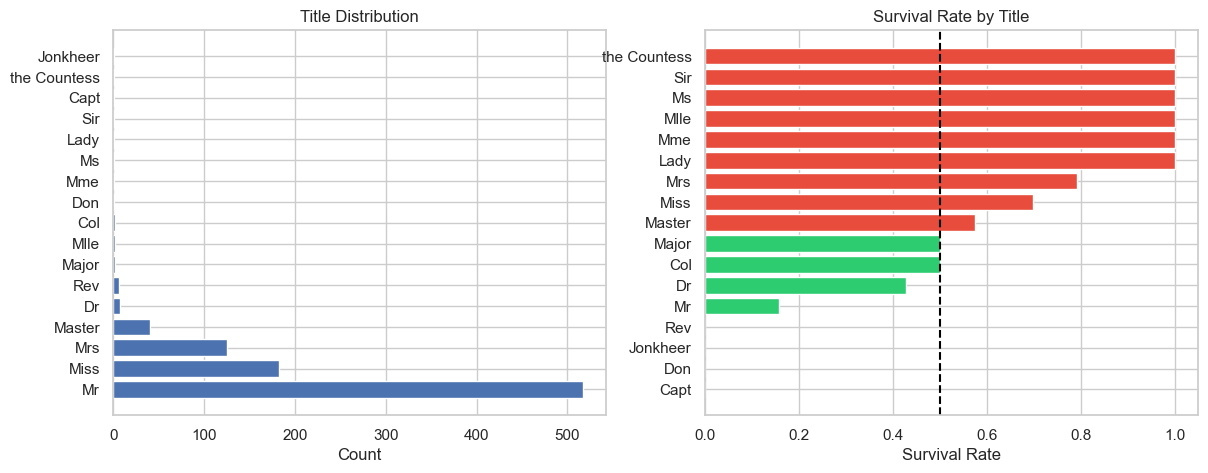

In [21]:

df["Title"] = df["Name"].apply(lambda x: x.split(",")[1].split(".")[0].strip())
survival_by_title = df.groupby("Title")["Survived"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Title Distribution

title_counts = df["Title"].value_counts()
axes[0].barh(title_counts.index, title_counts.values)
axes[0].set_xlabel("Count")
axes[0].set_title("Title Distribution")

# Survival Rate by Title
mean_survival = df["Survived"].mean()
colors = ["#e74c3c" if rate > 0.5 else "#2ecc71" for rate in survival_by_title.values]
axes[1].barh(survival_by_title.index, survival_by_title.values, color=colors)
axes[1].axvline(x=0.5, linestyle="--", color="black")
axes[1].set_xlabel("Survival Rate")
axes[1].set_title("Survival Rate by Title")

## Feature Analysis Findings

* 38.4% survived, 61.6% did not
* Gender and passenger class had a strong correlation on survival (women had a 74% chance to survive versus 18% for men, and the probability of first class surviving was magnitudes higher than third class).
* People who embarked at C had a much higher chance of surviving likely because there was a greater percentage of 1st class.
* Small families of 2 to 4 had the greatest survival rates.
* 77% of cabin, 20% of age, and 1% of embarked data was missing.